# 🚜 Predicting the Sale Price of Bulldozers Using Machine Learning.

In this notebook, we're going to go through an example machine learning project with the goal of predicting the sale price of bulldozers.

## 1. Problem Defination

> How well can we predict the future sale price of a bulldozer, given its characteristics and previous example of how much similar bulldozers have been sold for?

## 2. Data

The data is downloaded from  kaggle Blubook for Bulldozers competition: [kaggle bluebook for bulldozer](kaggle.com/c/bluebook-for-bulldozers/data)

## 3. Evaluation

The evaluation metric for this competition is the RMSLE (root mean square log error) between the actual and predicted auction prices.

For more on the evaluation of this project [check here](kaggle.com/c/bluebook-for-bulldozers/overview/evaluation)

**Note:** The goal for most regression evaluation metrics is to minimize the error. For example our goal for this project will be to build a machine learning model which minimizes RSMLE.

## 4. Features

The Feature for the dataset to with in this project was already given from kaggle. To find/read the features you can check the data folder of this project.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

In [2]:
# import training and validation dataset
df = pd.read_csv('/Users/Dsct.Engr.Al-amin/Desktop/working_env/Dsct_wrk_env/AL-AMIN-ML-PROJECTS/data/TrainAndValid.csv',
                 low_memory=False)

## EDA:

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412698 entries, 0 to 412697
Data columns (total 53 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   SalesID                   412698 non-null  int64  
 1   SalePrice                 412698 non-null  float64
 2   MachineID                 412698 non-null  int64  
 3   ModelID                   412698 non-null  int64  
 4   datasource                412698 non-null  int64  
 5   auctioneerID              392562 non-null  float64
 6   YearMade                  412698 non-null  int64  
 7   MachineHoursCurrentMeter  147504 non-null  float64
 8   UsageBand                 73670 non-null   object 
 9   saledate                  412698 non-null  object 
 10  fiModelDesc               412698 non-null  object 
 11  fiBaseModel               412698 non-null  object 
 12  fiSecondaryDesc           271971 non-null  object 
 13  fiModelSeries             58667 non-null   o

In [4]:
df.isna().sum()

SalesID                          0
SalePrice                        0
MachineID                        0
ModelID                          0
datasource                       0
auctioneerID                 20136
YearMade                         0
MachineHoursCurrentMeter    265194
UsageBand                   339028
saledate                         0
fiModelDesc                      0
fiBaseModel                      0
fiSecondaryDesc             140727
fiModelSeries               354031
fiModelDescriptor           337882
ProductSize                 216605
fiProductClassDesc               0
state                            0
ProductGroup                     0
ProductGroupDesc                 0
Drive_System                305611
Enclosure                      334
Forks                       214983
Pad_Type                    331602
Ride_Control                259970
Stick                       331602
Transmission                224691
Turbocharged                331602
Blade_Extension     

In [5]:
df.columns

Index(['SalesID', 'SalePrice', 'MachineID', 'ModelID', 'datasource',
       'auctioneerID', 'YearMade', 'MachineHoursCurrentMeter', 'UsageBand',
       'saledate', 'fiModelDesc', 'fiBaseModel', 'fiSecondaryDesc',
       'fiModelSeries', 'fiModelDescriptor', 'ProductSize',
       'fiProductClassDesc', 'state', 'ProductGroup', 'ProductGroupDesc',
       'Drive_System', 'Enclosure', 'Forks', 'Pad_Type', 'Ride_Control',
       'Stick', 'Transmission', 'Turbocharged', 'Blade_Extension',
       'Blade_Width', 'Enclosure_Type', 'Engine_Horsepower', 'Hydraulics',
       'Pushblock', 'Ripper', 'Scarifier', 'Tip_Control', 'Tire_Size',
       'Coupler', 'Coupler_System', 'Grouser_Tracks', 'Hydraulics_Flow',
       'Track_Type', 'Undercarriage_Pad_Width', 'Stick_Length', 'Thumb',
       'Pattern_Changer', 'Grouser_Type', 'Backhoe_Mounting', 'Blade_Type',
       'Travel_Controls', 'Differential_Type', 'Steering_Controls'],
      dtype='object')

In [6]:
df.saledate.dtype

dtype('O')

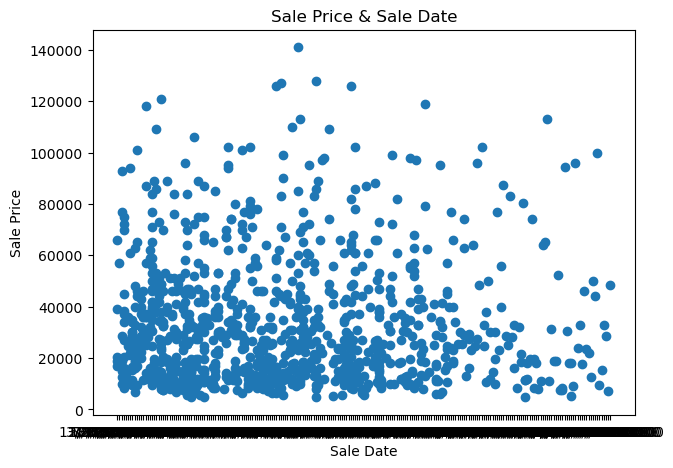

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
plt.scatter(df.saledate[:1000], df.SalePrice[:1000])
plt.xlabel('Sale Date')
plt.ylabel('Sale Price')
plt.title('Sale Price & Sale Date');

In [8]:
# fig, ax = plt.subplots()
# ax.scatter(df['saledate'][:1000], df['SalePrice'][:1000]);

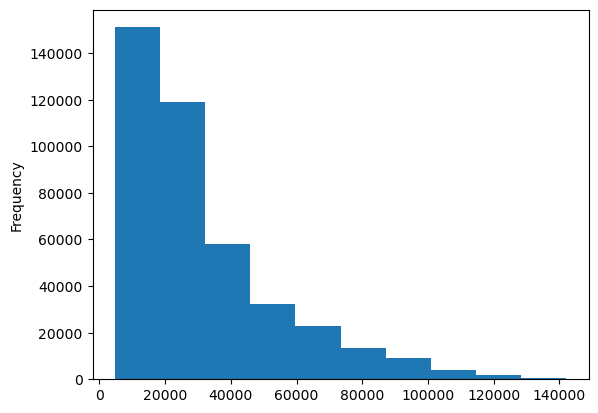

In [9]:
df.SalePrice.plot.hist();

### Parsing dates

When we work with time series data, we want to enrich the time & date component as much as possible.ProcessLookupError

We can do that by telling pandas which of our columns has date in it using the `parse_dates` parameter.

In [10]:
# import data again but this time parse date
df = pd.read_csv('/Users/Dsct.Engr.Al-amin/Desktop/working_env/Dsct_wrk_env/AL-AMIN-ML-PROJECTS/data/TrainAndValid.csv',
                 low_memory=False,
                 parse_dates=['saledate'])

In [11]:
df.saledate

0        2006-11-16
1        2004-03-26
2        2004-02-26
3        2011-05-19
4        2009-07-23
            ...    
412693   2012-03-07
412694   2012-01-28
412695   2012-01-28
412696   2012-03-07
412697   2012-01-28
Name: saledate, Length: 412698, dtype: datetime64[ns]

In [12]:
df.saledate.dtype

dtype('<M8[ns]')

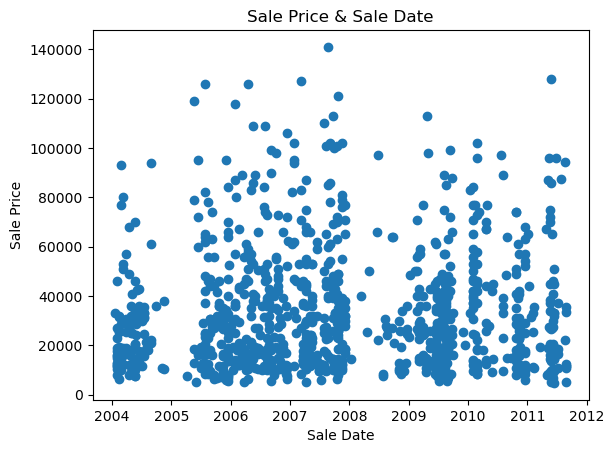

In [13]:
fig, ax = plt.subplots()
ax.scatter(df.saledate[:1000], df.SalePrice[:1000])
plt.xlabel('Sale Date')
plt.ylabel('Sale Price')
plt.title('Sale Price & Sale Date');

In [14]:
# fig, ax = plt.subplots()
# ax.scatter(df.saledate[:1000], df.SalePrice[:1000]);

In [15]:
df.head()

,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,saledate,...,Undercarriage_Pad_Width,Stick_Length,Thumb,Pattern_Changer,Grouser_Type,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls
0,1139246,66000.0,999089,3157,121,3.0,2004,68.0,Low,2006-11-16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139248,57000.0,117657,77,121,3.0,1996,4640.0,Low,2004-03-26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
2,1139249,10000.0,434808,7009,121,3.0,2001,2838.0,High,2004-02-26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1139251,38500.0,1026470,332,121,3.0,2001,3486.0,High,2011-05-19,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139253,11000.0,1057373,17311,121,3.0,2007,722.0,Medium,2009-07-23,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
df.head().T

,0,1,2,3,4
SalesID,1139246,1139248,1139249,1139251,1139253
SalePrice,66000.0,57000.0,10000.0,38500.0,11000.0
MachineID,999089,117657,434808,1026470,1057373
ModelID,3157,77,7009,332,17311
datasource,121,121,121,121,121
auctioneerID,3.0,3.0,3.0,3.0,3.0
YearMade,2004,1996,2001,2001,2007
MachineHoursCurrentMeter,68.0,4640.0,2838.0,3486.0,722.0
UsageBand,Low,Low,High,High,Medium
saledate,2006-11-16 00:00:00,2004-03-26 00:00:00,2004-02-26 00:00:00,2011-05-19 00:00:00,2009-07-23 00:00:00


In [17]:
df.saledate.head(20)

0    2006-11-16
1    2004-03-26
2    2004-02-26
3    2011-05-19
4    2009-07-23
5    2008-12-18
6    2004-08-26
7    2005-11-17
8    2009-08-27
9    2007-08-09
10   2008-08-21
11   2006-08-24
12   2005-10-20
13   2006-01-26
14   2006-01-03
15   2006-11-16
16   2007-06-14
17   2010-01-28
18   2006-03-09
19   2005-11-17
Name: saledate, dtype: datetime64[ns]

### Sort Dataframe by saledate

When working with time series data, it's a good idea to sort by date.

In [18]:
# sort DataFrame in Date oder
df.sort_values(by=['saledate'], inplace=True, ascending=True)
df.saledate.head(20)

205615   1989-01-17
274835   1989-01-31
141296   1989-01-31
212552   1989-01-31
62755    1989-01-31
54653    1989-01-31
81383    1989-01-31
204924   1989-01-31
135376   1989-01-31
113390   1989-01-31
113394   1989-01-31
116419   1989-01-31
32138    1989-01-31
127610   1989-01-31
76171    1989-01-31
127000   1989-01-31
128130   1989-01-31
127626   1989-01-31
55455    1989-01-31
55454    1989-01-31
Name: saledate, dtype: datetime64[ns]

### Make a copy of the Original DataFrame

We can a copy of the original DataFrame so when we manupulate the copy, we've still got our original data. 

In [19]:
# make a copy
df_copy = df.copy()
df_copy.saledate.head(20)

205615   1989-01-17
274835   1989-01-31
141296   1989-01-31
212552   1989-01-31
62755    1989-01-31
54653    1989-01-31
81383    1989-01-31
204924   1989-01-31
135376   1989-01-31
113390   1989-01-31
113394   1989-01-31
116419   1989-01-31
32138    1989-01-31
127610   1989-01-31
76171    1989-01-31
127000   1989-01-31
128130   1989-01-31
127626   1989-01-31
55455    1989-01-31
55454    1989-01-31
Name: saledate, dtype: datetime64[ns]

### Add datetime Parameter for `saledate` Column

In [20]:
df_copy['saleYear'] = df_copy['saledate'].dt.year
df_copy['saleMonth'] = df_copy['saledate'].dt.month
df_copy['saleDay'] = df_copy['saledate'].dt.day
df_copy['saleDayOfWeek'] = df_copy['saledate'].dt.dayofweek
df_copy['saleDayOfYear'] = df_copy['saledate'].dt.dayofyear

In [22]:
# df_copy['saleYear'] = df_copy.saledate.dt.year
# df_copy['saleMonth'] = df_copy.saledate.dt.month
# df_copy['saleDay'] = df_copy.saledate.dt.day
# df_copy['saleDayOfWeek'] = df_copy.saledate.dt.dayofweek
# df_copy['saleDayOfYear'] = df_copy.saledate.dt.dayofyear

In [21]:
df_copy.head().T

,205615,274835,141296,212552,62755
SalesID,1646770,1821514,1505138,1671174,1329056
SalePrice,9500.0,14000.0,50000.0,16000.0,22000.0
MachineID,1126363,1194089,1473654,1327630,1336053
ModelID,8434,10150,4139,8591,4089
datasource,132,132,132,132,132
auctioneerID,18.0,99.0,99.0,99.0,99.0
YearMade,1974,1980,1978,1980,1984
MachineHoursCurrentMeter,NaN,NaN,NaN,NaN,NaN
UsageBand,NaN,NaN,NaN,NaN,NaN
saledate,1989-01-17 00:00:00,1989-01-31 00:00:00,1989-01-31 00:00:00,1989-01-31 00:00:00,1989-01-31 00:00:00


In [22]:
# Now we've enriched our DataFrame with date time feature, we can remove (saledate) column
df_copy.drop('saledate', axis=1, inplace=True)

In [23]:
df_copy.tail()

,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,fiModelDesc,...,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls,saleYear,saleMonth,saleDay,saleDayOfWeek,saleDayOfYear
410879,6302984,16000.0,1915521,5266,149,99.0,2001,NaN,NaN,D38E,...,None or Unspecified,PAT,None or Unspecified,NaN,NaN,2012,4,28,5,119
412476,6324811,6000.0,1919104,19330,149,99.0,2004,NaN,NaN,2064,...,NaN,NaN,NaN,NaN,NaN,2012,4,28,5,119
411927,6313029,16000.0,1918416,17244,149,99.0,2004,NaN,NaN,337G,...,NaN,NaN,NaN,NaN,NaN,2012,4,28,5,119
407124,6266251,55000.0,509560,3357,149,99.0,1993,NaN,NaN,12G,...,NaN,NaN,NaN,NaN,NaN,2012,4,28,5,119
409203,6283635,34000.0,1869284,4701,149,99.0,1000,NaN,NaN,544H,...,NaN,NaN,NaN,Standard,Conventional,2012,4,28,5,119


In [24]:
df_copy.state.value_counts()

state
Florida           67320
Texas             53110
California        29761
Washington        16222
Georgia           14633
Maryland          13322
Mississippi       13240
Ohio              12369
Illinois          11540
Colorado          11529
New Jersey        11156
North Carolina    10636
Tennessee         10298
Alabama           10292
Pennsylvania      10234
South Carolina     9951
Arizona            9364
New York           8639
Connecticut        8276
Minnesota          7885
Missouri           7178
Nevada             6932
Louisiana          6627
Kentucky           5351
Maine              5096
Indiana            4124
Arkansas           3933
New Mexico         3631
Utah               3046
Unspecified        2801
Wisconsin          2745
New Hampshire      2738
Virginia           2353
Idaho              2025
Oregon             1911
Michigan           1831
Wyoming            1672
Montana            1336
Iowa               1336
Oklahoma           1326
Nebraska            866
West Virgi

## 5. Modelling

We've done enough EDA (we could always do more) but let's start to do some model-driven EDA.

In [25]:
# Let's build a machine learning model
from sklearn.ensemble import RandomForestRegressor

# instanciate the model
model = RandomForestRegressor(n_jobs=-1,
                              random_state=42)

# fit withe the data
model.fit(df_copy.drop('SalePrice', axis=1),
          df.SalePrice)

ValueError: could not convert string to float: 'Low'

In [26]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 412698 entries, 205615 to 409203
Data columns (total 57 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   SalesID                   412698 non-null  int64  
 1   SalePrice                 412698 non-null  float64
 2   MachineID                 412698 non-null  int64  
 3   ModelID                   412698 non-null  int64  
 4   datasource                412698 non-null  int64  
 5   auctioneerID              392562 non-null  float64
 6   YearMade                  412698 non-null  int64  
 7   MachineHoursCurrentMeter  147504 non-null  float64
 8   UsageBand                 73670 non-null   object 
 9   fiModelDesc               412698 non-null  object 
 10  fiBaseModel               412698 non-null  object 
 11  fiSecondaryDesc           271971 non-null  object 
 12  fiModelSeries             58667 non-null   object 
 13  fiModelDescriptor         74816 non-null   o

In [27]:
df_copy['UsageBand'].dtype

dtype('O')

In [28]:
df_copy.isna().sum()

SalesID                          0
SalePrice                        0
MachineID                        0
ModelID                          0
datasource                       0
auctioneerID                 20136
YearMade                         0
MachineHoursCurrentMeter    265194
UsageBand                   339028
fiModelDesc                      0
fiBaseModel                      0
fiSecondaryDesc             140727
fiModelSeries               354031
fiModelDescriptor           337882
ProductSize                 216605
fiProductClassDesc               0
state                            0
ProductGroup                     0
ProductGroupDesc                 0
Drive_System                305611
Enclosure                      334
Forks                       214983
Pad_Type                    331602
Ride_Control                259970
Stick                       331602
Transmission                224691
Turbocharged                331602
Blade_Extension             386715
Blade_Width         

### Convert Strings to Categories

One way we can turn all of our data into numbers is by converting them into pandas category

In [29]:
df_copy.head().T

,205615,274835,141296,212552,62755
SalesID,1646770,1821514,1505138,1671174,1329056
SalePrice,9500.0,14000.0,50000.0,16000.0,22000.0
MachineID,1126363,1194089,1473654,1327630,1336053
ModelID,8434,10150,4139,8591,4089
datasource,132,132,132,132,132
auctioneerID,18.0,99.0,99.0,99.0,99.0
YearMade,1974,1980,1978,1980,1984
MachineHoursCurrentMeter,NaN,NaN,NaN,NaN,NaN
UsageBand,NaN,NaN,NaN,NaN,NaN
fiModelDesc,TD20,A66,D7G,A62,D3B


In [30]:
pd.api.types.is_string_dtype(df_copy['UsageBand'])

False

In [32]:
pd.api.types.is_integer_dtype(df_copy['saleYear'])

True

In [33]:
pd.api.types.is_string_dtype(df_copy['fiBaseModel'])

True

In [34]:
# Find columns which contai strings
for label, content in df_copy.items():
    if pd.api.types.is_string_dtype(content):
        print(label)

fiModelDesc
fiBaseModel
fiProductClassDesc
state
ProductGroup
ProductGroupDesc


In [35]:
# Find columns which contai strings

# for label, content in df_copy.items():
#     if pd.api.types.is_string_dtype(content):
#         print(label)

In [36]:
# if you're wondering what df_copy.items() does, here is an example
random_dict = {'Name': 'Al-amin',
               'Status': 'Data Scientist'}

for key, value in random_dict.items():
    print(f"This is a key: {key}.",
          f"This is a value: {value}")

This is a key: Name. This is a value: Al-amin
This is a key: Status. This is a value: Data Scientist


In [37]:
# This will turns all the string values into category values
for label, content in df_copy.items():
    if pd.api.types.is_string_dtype(content):
        df_copy[label] = content.astype('category').cat.as_ordered()

In [38]:
# This will turns all the string values into category values
for label, content in df_copy.items():
    if pd.api.types.is_string_dtype(content):
        df_copy[label] = content.astype('category').cat.as_ordered()

In [39]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 412698 entries, 205615 to 409203
Data columns (total 57 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   SalesID                   412698 non-null  int64   
 1   SalePrice                 412698 non-null  float64 
 2   MachineID                 412698 non-null  int64   
 3   ModelID                   412698 non-null  int64   
 4   datasource                412698 non-null  int64   
 5   auctioneerID              392562 non-null  float64 
 6   YearMade                  412698 non-null  int64   
 7   MachineHoursCurrentMeter  147504 non-null  float64 
 8   UsageBand                 73670 non-null   object  
 9   fiModelDesc               412698 non-null  category
 10  fiBaseModel               412698 non-null  category
 11  fiSecondaryDesc           271971 non-null  object  
 12  fiModelSeries             58667 non-null   object  
 13  fiModelDescriptor         748

In [40]:
df_copy.state.cat.categories

Index(['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado',
       'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho',
       'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana',
       'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota',
       'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada',
       'New Hampshire', 'New Jersey', 'New Mexico', 'New York',
       'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon',
       'Pennsylvania', 'Puerto Rico', 'Rhode Island', 'South Carolina',
       'South Dakota', 'Tennessee', 'Texas', 'Unspecified', 'Utah', 'Vermont',
       'Virginia', 'Washington', 'Washington DC', 'West Virginia', 'Wisconsin',
       'Wyoming'],
      dtype='object')

In [41]:
df.state.value_counts()

state
Florida           67320
Texas             53110
California        29761
Washington        16222
Georgia           14633
Maryland          13322
Mississippi       13240
Ohio              12369
Illinois          11540
Colorado          11529
New Jersey        11156
North Carolina    10636
Tennessee         10298
Alabama           10292
Pennsylvania      10234
South Carolina     9951
Arizona            9364
New York           8639
Connecticut        8276
Minnesota          7885
Missouri           7178
Nevada             6932
Louisiana          6627
Kentucky           5351
Maine              5096
Indiana            4124
Arkansas           3933
New Mexico         3631
Utah               3046
Unspecified        2801
Wisconsin          2745
New Hampshire      2738
Virginia           2353
Idaho              2025
Oregon             1911
Michigan           1831
Wyoming            1672
Montana            1336
Iowa               1336
Oklahoma           1326
Nebraska            866
West Virgi

In [42]:
df_copy.state.cat.codes

205615    43
274835     8
141296     8
212552     8
62755      8
          ..
410879     4
412476     4
411927     4
407124     4
409203     4
Length: 412698, dtype: int8

Thanks to Pandas Categories we now have a way to access all of our data in the form of numbers.

But we still have a bunch of missing data...

In [43]:
# Let's check some missing values
df_copy.isnull().sum()/len(df_copy)

SalesID                     0.000000
SalePrice                   0.000000
MachineID                   0.000000
ModelID                     0.000000
datasource                  0.000000
auctioneerID                0.048791
YearMade                    0.000000
MachineHoursCurrentMeter    0.642586
UsageBand                   0.821492
fiModelDesc                 0.000000
fiBaseModel                 0.000000
fiSecondaryDesc             0.340993
fiModelSeries               0.857845
fiModelDescriptor           0.818715
ProductSize                 0.524851
fiProductClassDesc          0.000000
state                       0.000000
ProductGroup                0.000000
ProductGroupDesc            0.000000
Drive_System                0.740520
Enclosure                   0.000809
Forks                       0.520921
Pad_Type                    0.803498
Ride_Control                0.629928
Stick                       0.803498
Transmission                0.544444
Turbocharged                0.803498
B

### Save Preprocessed data

In [44]:
# Ex port current copy DataFrame
# df_copy.to_csv('blubook_train.csv')

In [45]:
# Ex port current copy DataFrame
df_copy.to_csv('blubook_train.csv',
               index=False)

In [46]:
df_tmp = pd.read_csv('blubook_train.csv', 
                     low_memory=False)
df_tmp.head()

,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,fiModelDesc,...,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls,saleYear,saleMonth,saleDay,saleDayOfWeek,saleDayOfYear
0,1646770,9500.0,1126363,8434,132,18.0,1974,NaN,NaN,TD20,...,None or Unspecified,Straight,None or Unspecified,NaN,NaN,1989,1,17,1,17
1,1821514,14000.0,1194089,10150,132,99.0,1980,NaN,NaN,A66,...,NaN,NaN,NaN,Standard,Conventional,1989,1,31,1,31
2,1505138,50000.0,1473654,4139,132,99.0,1978,NaN,NaN,D7G,...,None or Unspecified,Straight,None or Unspecified,NaN,NaN,1989,1,31,1,31
3,1671174,16000.0,1327630,8591,132,99.0,1980,NaN,NaN,A62,...,NaN,NaN,NaN,Standard,Conventional,1989,1,31,1,31
4,1329056,22000.0,1336053,4089,132,99.0,1984,NaN,NaN,D3B,...,None or Unspecified,PAT,Lever,NaN,NaN,1989,1,31,1,31


In [47]:
df_tmp.head().T

,0,1,2,3,4
SalesID,1646770,1821514,1505138,1671174,1329056
SalePrice,9500.0,14000.0,50000.0,16000.0,22000.0
MachineID,1126363,1194089,1473654,1327630,1336053
ModelID,8434,10150,4139,8591,4089
datasource,132,132,132,132,132
auctioneerID,18.0,99.0,99.0,99.0,99.0
YearMade,1974,1980,1978,1980,1984
MachineHoursCurrentMeter,NaN,NaN,NaN,NaN,NaN
UsageBand,NaN,NaN,NaN,NaN,NaN
fiModelDesc,TD20,A66,D7G,A62,D3B


In [48]:
df_tmp.isna().sum()

SalesID                          0
SalePrice                        0
MachineID                        0
ModelID                          0
datasource                       0
auctioneerID                 20136
YearMade                         0
MachineHoursCurrentMeter    265194
UsageBand                   339028
fiModelDesc                      0
fiBaseModel                      0
fiSecondaryDesc             140727
fiModelSeries               354031
fiModelDescriptor           337882
ProductSize                 216605
fiProductClassDesc               0
state                            0
ProductGroup                     0
ProductGroupDesc                 0
Drive_System                305611
Enclosure                      334
Forks                       214983
Pad_Type                    331602
Ride_Control                259970
Stick                       331602
Transmission                224691
Turbocharged                331602
Blade_Extension             386715
Blade_Width         

## Fill missing values

### Fill numerical missing vlaues

In [49]:
for label, content in df_tmp.items():
    if pd.api.types.is_numeric_dtype(content):
        print(label)

SalesID
SalePrice
MachineID
ModelID
datasource
auctioneerID
YearMade
MachineHoursCurrentMeter
saleYear
saleMonth
saleDay
saleDayOfWeek
saleDayOfYear


In [50]:
# Check for which numeric column have a null value
for label, content in df_tmp.items():
    if pd.api.types.is_numeric_dtype(content):
        if pd.isnull(content).sum():
            print(label)

auctioneerID
MachineHoursCurrentMeter


In [51]:
# Check for which numeric column have a null value
# for label, content in df_tmp.items():
#     if pd.api.types.is_numeric_dtype(content):
#         if pd.isnull(content).sum():
#             print(label)

In [52]:
# Fill numeric row with the median
for label, content in df_tmp.items():
    if pd.api.types.is_numeric_dtype(content):
        if pd.isnull(content).sum():
            # add a binary column which tell us if the data was missing or not
            df_tmp[label+' is_missing'] = pd.isnull(content)
            # fill missing numeric values with median
            df_tmp[label] = content.fillna(content.median())

In [ ]:
# Fill numeric row with the median
# for label, content in df_tmp.items():
#     if pd.api.types.is_numeric_dtype(content):
#         if pd.isnull(content).sum():
#             # add a binary column which tell us if the data was missing or not.
#             df_tmp[label+'is_missing'] = pd.isnull(content)
#             # fill missing numeric values with median
#             df_tmp[label] =  content.fillna(content.median())


In [53]:
# Check if there is any other numeric missing values
for label, content in df_tmp.items():
    if pd.api.types.is_numeric_dtype(content):
        if pd.isnull(content).sum():
            print(label)

In [54]:
df_tmp['MachineHoursCurrentMeter is_missing'].value_counts()

MachineHoursCurrentMeter is_missing
True     265194
False    147504
Name: count, dtype: int64

In [55]:
# Check to see how many examples were missing
df_tmp['auctioneerID is_missing'].value_counts()

auctioneerID is_missing
False    392562
True      20136
Name: count, dtype: int64

### Filling and turning categorical variables into numbers

In [56]:
# Check for column which aren't numbers
for label, content in df_tmp.items():
    if not pd.api.types.is_numeric_dtype(content):
        print(label)

UsageBand
fiModelDesc
fiBaseModel
fiSecondaryDesc
fiModelSeries
fiModelDescriptor
ProductSize
fiProductClassDesc
state
ProductGroup
ProductGroupDesc
Drive_System
Enclosure
Forks
Pad_Type
Ride_Control
Stick
Transmission
Turbocharged
Blade_Extension
Blade_Width
Enclosure_Type
Engine_Horsepower
Hydraulics
Pushblock
Ripper
Scarifier
Tip_Control
Tire_Size
Coupler
Coupler_System
Grouser_Tracks
Hydraulics_Flow
Track_Type
Undercarriage_Pad_Width
Stick_Length
Thumb
Pattern_Changer
Grouser_Type
Backhoe_Mounting
Blade_Type
Travel_Controls
Differential_Type
Steering_Controls


In [57]:
# Turn categorical variables into numbers and fill missing
for label, content in df_tmp.items():
    if not pd.api.types.is_numeric_dtype(content):
        # Add binary column to indicate wether sample had missing value of not.
        df_tmp[label+' is_missing'] = pd.isnull(content)
        # Turns categories into numbers and add +1
        df_tmp[label] = pd.Categorical(content).codes+1

In [58]:
df_tmp

,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,fiModelDesc,...,Undercarriage_Pad_Width is_missing,Stick_Length is_missing,Thumb is_missing,Pattern_Changer is_missing,Grouser_Type is_missing,Backhoe_Mounting is_missing,Blade_Type is_missing,Travel_Controls is_missing,Differential_Type is_missing,Steering_Controls is_missing
0,1646770,9500.0,1126363,8434,132,18.0,1974,0.0,0,4593,...,True,True,True,True,True,False,False,False,True,True
1,1821514,14000.0,1194089,10150,132,99.0,1980,0.0,0,1820,...,True,True,True,True,True,True,True,True,False,False
2,1505138,50000.0,1473654,4139,132,99.0,1978,0.0,0,2348,...,True,True,True,True,True,False,False,False,True,True
3,1671174,16000.0,1327630,8591,132,99.0,1980,0.0,0,1819,...,True,True,True,True,True,True,True,True,False,False
4,1329056,22000.0,1336053,4089,132,99.0,1984,0.0,0,2119,...,True,True,True,True,True,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
412693,6302984,16000.0,1915521,5266,149,99.0,2001,0.0,0,2101,...,True,True,True,True,True,False,False,False,True,True
412694,6324811,6000.0,1919104,19330,149,99.0,2004,0.0,0,240,...,True,True,True,True,True,True,True,True,True,True
412695,6313029,16000.0,1918416,17244,149,99.0,2004,0.0,0,627,...,True,True,True,True,True,True,True,True,True,True
412696,6266251,55000.0,509560,3357,149,99.0,1993,0.0,0,83,...,True,True,True,True,True,True,True,True,True,True


In [59]:
df_tmp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412698 entries, 0 to 412697
Columns: 103 entries, SalesID to Steering_Controls is_missing
dtypes: bool(46), float64(3), int16(4), int64(10), int8(40)
memory usage: 77.9 MB


In [60]:
df_tmp.head().T

,0,1,2,3,4
SalesID,1646770,1821514,1505138,1671174,1329056
SalePrice,9500.0,14000.0,50000.0,16000.0,22000.0
MachineID,1126363,1194089,1473654,1327630,1336053
ModelID,8434,10150,4139,8591,4089
datasource,132,132,132,132,132
...,...,...,...,...,...
Backhoe_Mounting is_missing,False,True,False,True,False
Blade_Type is_missing,False,True,False,True,False
Travel_Controls is_missing,False,True,False,True,False
Differential_Type is_missing,True,False,True,False,True


In [61]:
df_tmp.isna().sum()

SalesID                         0
SalePrice                       0
MachineID                       0
ModelID                         0
datasource                      0
                               ..
Backhoe_Mounting is_missing     0
Blade_Type is_missing           0
Travel_Controls is_missing      0
Differential_Type is_missing    0
Steering_Controls is_missing    0
Length: 103, dtype: int64

Now that all of our data is numeric as well as our dataframe has no missing values, we should be able to build a machine learning model.

In [62]:
df_tmp.head()

,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,fiModelDesc,...,Undercarriage_Pad_Width is_missing,Stick_Length is_missing,Thumb is_missing,Pattern_Changer is_missing,Grouser_Type is_missing,Backhoe_Mounting is_missing,Blade_Type is_missing,Travel_Controls is_missing,Differential_Type is_missing,Steering_Controls is_missing
0,1646770,9500.0,1126363,8434,132,18.0,1974,0.0,0,4593,...,True,True,True,True,True,False,False,False,True,True
1,1821514,14000.0,1194089,10150,132,99.0,1980,0.0,0,1820,...,True,True,True,True,True,True,True,True,False,False
2,1505138,50000.0,1473654,4139,132,99.0,1978,0.0,0,2348,...,True,True,True,True,True,False,False,False,True,True
3,1671174,16000.0,1327630,8591,132,99.0,1980,0.0,0,1819,...,True,True,True,True,True,True,True,True,False,False
4,1329056,22000.0,1336053,4089,132,99.0,1984,0.0,0,2119,...,True,True,True,True,True,False,False,False,True,True


In [63]:
len(df_tmp)

412698

In [64]:
%%time

# Instantiate a model
model = RandomForestRegressor(n_jobs=-1,
                              random_state=42)

# Split data into features and labels
X = df_tmp.drop('SalePrice', axis=1)
y = df_tmp['SalePrice']

# Fit the model
model.fit(X, y)

CPU times: total: 30min 10s
Wall time: 11min 39s


RandomForestRegressor(n_jobs=-1, random_state=42)

In [65]:
model.score(df_tmp.drop('SalePrice', axis=1),
            df_tmp['SalePrice'])

0.9875468079970562

**Question**: Why does the above metric hold water? (Why isn't the metric reliable)

## Splitting data into train/validation sets

In [68]:
df_tmp.saleYear.head()

0    1989
1    1989
2    1989
3    1989
4    1989
Name: saleYear, dtype: int64

In [69]:
df_tmp.saleYear.value_counts()

saleYear
2009    43849
2008    39767
2011    35197
2010    33390
2007    32208
2006    21685
2005    20463
2004    19879
2001    17594
2000    17415
2002    17246
2003    15254
1998    13046
1999    12793
2012    11573
1997     9785
1996     8829
1995     8530
1994     7929
1993     6303
1992     5519
1991     5109
1989     4806
1990     4529
Name: count, dtype: int64

In [71]:
# Split data into train and validation set

#validation set
df_val = df_tmp[df_tmp.saleYear == 2012]

# train set
df_train = df_tmp[df_tmp['saleYear'] != 2012]

# csheck len
len(df_val), len(df_train)

(11573, 401125)

In [72]:
# Split data into X and y

# Features
X_train, y_train = df_train.drop('SalePrice', axis=1), df_train['SalePrice']

# Labels
X_valid, y_valid = df_val.drop('SalePrice', axis=1), df_val.SalePrice

# Check shapes
X_train.shape, y_train.shape, X_valid.shape, y_valid.shape

((401125, 102), (401125,), (11573, 102), (11573,))

In [73]:
y_train

0          9500.0
1         14000.0
2         50000.0
3         16000.0
4         22000.0
           ...   
401120    29000.0
401121    11000.0
401122    11000.0
401123    18000.0
401124    13500.0
Name: SalePrice, Length: 401125, dtype: float64

### Building an Evaluation Function

In [74]:
# create an evaluation function (the competition uses RMSLE)
from sklearn.metrics import mean_squared_log_error, mean_absolute_error, r2_score

def rmsle(y_test, y_preds):
    '''
    Calculate root mean squared log error between prediction and
    true labels
    '''
    return np.sqrt(mean_squared_log_error(y_test, y_preds))

# create function to evaluate model on a few different levels.  
def show_scores(model):
    train_preds = model.predict(X_train)
    val_preds = model.predict(X_valid)
    scores = {'Training MAE': mean_absolute_error(y_train, train_preds),
              'Valid MAE': mean_absolute_error(y_valid, val_preds),
              'Training RMSLE': rmsle(y_train, train_preds),
              'Valid RMSLE': rmsle(y_valid, val_preds),
              'Training R^2': r2_score(y_train, train_preds),
              'Valid R^2': r2_score(y_valid, val_preds)}
    return scores

## Testing our model on a subset (to turn the hyperparameters)

In [ ]:
# # This takes far too long... for experiment

# %%time

# model = RandomForestRegressor(n_jobs=-1,
#                               random_state=42)

# model.fit(X_train, y_train)

In [75]:
len(X_train)

401125

In [76]:
# change max_sample value (to reduce the time)

model = RandomForestRegressor(n_jobs=-1,
                              random_state=42,
                              max_samples=1000)

In [77]:
%%time

# Cutting down on the max number of samples each estimator can see improves training time.
model.fit(X_train, y_train)

CPU times: total: 9.45 s
Wall time: 3.78 s


RandomForestRegressor(max_samples=1000, n_jobs=-1, random_state=42)

In [78]:
show_scores(model)

{'Training MAE': 7665.083066051727,
 'Valid MAE': 9132.679371813705,
 'Training RMSLE': 0.3411018319032423,
 'Valid RMSLE': 0.3762446378810512,
 'Training R^2': 0.7559381504200411,
 'Valid R^2': 0.7507358682022224}

### Hyperparameter tuning with RandomizedSearchCV

In [79]:
%%time

from sklearn.model_selection import RandomizedSearchCV

# different RandomForestRegressor Hyperparameter

rg_grid = {'n_estimators': np.arange(10, 100, 10),
           'max_depth': [None, 3, 5, 10],
           'min_samples_split': np.arange(2, 20, 2),
           'min_samples_leaf': np.arange(1, 20, 2),
           'max_features': [0.5, 1, 'sqrt', 'auto'],
           'max_samples': [10000]}


# Instantiate RandomizedSearchCV model
rs_model = RandomizedSearchCV(RandomForestRegressor(n_jobs=-1,
                                                    random_state=42),
                              param_distributions=rg_grid,
                              n_iter=2,
                              cv=5,
                              verbose=True)

# Fit the RamdomizedSearchCV model
rs_model.fit(X_train, y_train)

Fitting 5 folds for each of 2 candidates, totalling 10 fits


c:\Users\Dsct.Engr.Al-amin\Desktop\working_env\Dsct_wrk_env\env\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
5 fits failed out of a total of 10.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Dsct.Engr.Al-amin\Desktop\working_env\Dsct_wrk_env\env\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Dsct.Engr.Al-amin\Desktop\working_env\Dsct_wrk_env\env\Lib\site-packages\sklearn\base.py", line 1466, in wrapper
    estimator._validate_params()
  File "c:\Users\Dsct.Engr.Al-amin\Desktop\working_env\Dsct_wrk_env\env

CPU times: total: 54.2 s
Wall time: 21.9 s


RandomizedSearchCV(cv=5,
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_iter=2,
                   param_distributions={'max_depth': [None, 3, 5, 10],
                                        'max_features': [0.5, 1, 'sqrt',
                                                         'auto'],
                                        'max_samples': [10000],
                                        'min_samples_leaf': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19]),
                                        'min_samples_split': array([ 2,  4,  6,  8, 10, 12, 14, 16, 18]),
                                        'n_estimators': array([10, 20, 30, 40, 50, 60, 70, 80, 90])},
                   verbose=True)

In [80]:
rs_model.best_params_

{'n_estimators': 80,
 'min_samples_split': 12,
 'min_samples_leaf': 15,
 'max_samples': 10000,
 'max_features': 0.5,
 'max_depth': 3}

In [81]:
# Evaluate the rs_model
show_scores(rs_model)

{'Training MAE': 11803.783339107997,
 'Valid MAE': 13506.508595801735,
 'Training RMSLE': 0.5068943233003104,
 'Valid RMSLE': 0.5124200828634472,
 'Training R^2': 0.4888766395739804,
 'Valid R^2': 0.48941956679683185}

## Trian a model with the best Hyperparameters

**Note:** These were found after 100 iterations of `RandomizedSearchCV`

In [82]:
%%time 

# Most ideal hyperparameters
ideal_model = RandomForestRegressor(n_jobs=-1,
                                    random_state=42,
                                    n_estimators=40,
                                    max_features=0.5,
                                    min_samples_leaf=1,
                                    min_samples_split=14,
                                    max_samples=None)

# fit the ideal model
ideal_model.fit(X_train, y_train)

CPU times: total: 5min 11s
Wall time: 1min 51s


RandomForestRegressor(max_features=0.5, min_samples_split=14, n_estimators=40,
                      n_jobs=-1, random_state=42)

In [83]:
# score for ideal model (trained on all the data)
show_scores(ideal_model)

{'Training MAE': 2953.8161137163484,
 'Valid MAE': 5951.247761444453,
 'Training RMSLE': 0.14469006962371858,
 'Valid RMSLE': 0.24524163989538328,
 'Training R^2': 0.9588145522577225,
 'Valid R^2': 0.8818019502450094}

In [84]:
# score on rs_model (only trained on 10,000 examples)
show_scores(rs_model)

{'Training MAE': 11803.783339107997,
 'Valid MAE': 13506.508595801735,
 'Training RMSLE': 0.5068943233003104,
 'Valid RMSLE': 0.5124200828634472,
 'Training R^2': 0.4888766395739804,
 'Valid R^2': 0.48941956679683174}

## Make predictions on test data

In [85]:
df_test = pd.read_csv('/Users/Dsct.Engr.Al-amin/Desktop/working_env/Dsct_wrk_env/AL-AMIN-ML-PROJECTS/data/Test.csv',
                      low_memory=False,
                      parse_dates=['saledate'])
df_test.head()

,SalesID,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,saledate,fiModelDesc,...,Undercarriage_Pad_Width,Stick_Length,Thumb,Pattern_Changer,Grouser_Type,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls
0,1227829,1006309,3168,121,3,1999,3688.0,Low,2012-05-03,580G,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1227844,1022817,7271,121,3,1000,28555.0,High,2012-05-10,936,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
2,1227847,1031560,22805,121,3,2004,6038.0,Medium,2012-05-10,EC210BLC,...,None or Unspecified,"9' 6""",Manual,None or Unspecified,Double,NaN,NaN,NaN,NaN,NaN
3,1227848,56204,1269,121,3,2006,8940.0,High,2012-05-10,330CL,...,None or Unspecified,None or Unspecified,Manual,Yes,Triple,NaN,NaN,NaN,NaN,NaN
4,1227863,1053887,22312,121,3,2005,2286.0,Low,2012-05-10,650K,...,NaN,NaN,NaN,NaN,NaN,None or Unspecified,PAT,None or Unspecified,NaN,NaN


In [148]:
# make prediction
test_preds = ideal_model.predict(df_test)

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- saledate
Feature names seen at fit time, yet now missing:
- Backhoe_Mounting is_missing
- Blade_Extension is_missing
- Blade_Type is_missing
- Blade_Width is_missing
- Coupler is_missing
- ...


### Preprocessing the data (getting the test dataset in the the same format as our training dataset)

In [86]:
def preprocess_data(df):
    '''
    performs transpormation on df and returns transformed df.
    '''

    df['saleYear'] = df.saledate.dt.year
    df['saleMonth'] = df.saledate.dt.month
    df['saleDay'] = df.saledate.dt.day
    df['saleDayOfWeek'] = df.saledate.dt.dayofweek
    df['saleDayOfYear'] = df.saledate.dt.dayofyear

    df.drop('saledate', axis=1, inplace=True)

    # Fill numeric row with the median
    for label, content in df.items():
        if pd.api.types.is_numeric_dtype(content):
            if pd.isnull(content).sum():
                # add a binary column which tell us if the data was missing or not.
                df[label+' is_missing'] = pd.isnull(content)
                # fill missing numeric values with median
                df[label] =  content.fillna(content.median())

        # Turn categorical variables into numbers and fill missing
        if not pd.api.types.is_numeric_dtype(content):
            # Add binary column to indicate wether sample had missing value of not.
            df[label+' is_missing'] = pd.isnull(content)
            # Turns categories into numbers and add +1
            df[label] = pd.Categorical(content).codes+1
    return df

In [87]:
# Preprocess test data
df_test = preprocess_data(df_test)
df_test.head()

,SalesID,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,fiModelDesc,fiBaseModel,...,Undercarriage_Pad_Width is_missing,Stick_Length is_missing,Thumb is_missing,Pattern_Changer is_missing,Grouser_Type is_missing,Backhoe_Mounting is_missing,Blade_Type is_missing,Travel_Controls is_missing,Differential_Type is_missing,Steering_Controls is_missing
0,1227829,1006309,3168,121,3,1999,3688.0,2,499,180,...,True,True,True,True,True,True,True,True,True,True
1,1227844,1022817,7271,121,3,1000,28555.0,1,831,292,...,True,True,True,True,True,True,True,True,False,False
2,1227847,1031560,22805,121,3,2004,6038.0,3,1177,404,...,False,False,False,False,False,True,True,True,True,True
3,1227848,56204,1269,121,3,2006,8940.0,1,287,113,...,False,False,False,False,False,True,True,True,True,True
4,1227863,1053887,22312,121,3,2005,2286.0,2,566,196,...,True,True,True,True,True,False,False,False,True,True


In [88]:
X_train.head()

,SalesID,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,fiModelDesc,fiBaseModel,...,Undercarriage_Pad_Width is_missing,Stick_Length is_missing,Thumb is_missing,Pattern_Changer is_missing,Grouser_Type is_missing,Backhoe_Mounting is_missing,Blade_Type is_missing,Travel_Controls is_missing,Differential_Type is_missing,Steering_Controls is_missing
0,1646770,1126363,8434,132,18.0,1974,0.0,0,4593,1744,...,True,True,True,True,True,False,False,False,True,True
1,1821514,1194089,10150,132,99.0,1980,0.0,0,1820,559,...,True,True,True,True,True,True,True,True,False,False
2,1505138,1473654,4139,132,99.0,1978,0.0,0,2348,713,...,True,True,True,True,True,False,False,False,True,True
3,1671174,1327630,8591,132,99.0,1980,0.0,0,1819,558,...,True,True,True,True,True,True,True,True,False,False
4,1329056,1336053,4089,132,99.0,1984,0.0,0,2119,683,...,True,True,True,True,True,False,False,False,True,True


In [89]:
# We can find how the column differs using set
set(X_train.columns) - set(df_test.columns)

{'auctioneerID is_missing'}

In [90]:
X_train['MachineHoursCurrentMeter is_missing'].value_counts()

MachineHoursCurrentMeter is_missing
True     258360
False    142765
Name: count, dtype: int64

In [91]:
for row in X_train['MachineHoursCurrentMeter is_missing']:
    if row == True:
        df_test['MachineHoursCurrentMeter is_missing'] = True
    elif row==False:
        df_test['MachineHoursCurrentMeter is_missing'] = False

In [92]:
df_test.head()

,SalesID,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,fiModelDesc,fiBaseModel,...,Undercarriage_Pad_Width is_missing,Stick_Length is_missing,Thumb is_missing,Pattern_Changer is_missing,Grouser_Type is_missing,Backhoe_Mounting is_missing,Blade_Type is_missing,Travel_Controls is_missing,Differential_Type is_missing,Steering_Controls is_missing
0,1227829,1006309,3168,121,3,1999,3688.0,2,499,180,...,True,True,True,True,True,True,True,True,True,True
1,1227844,1022817,7271,121,3,1000,28555.0,1,831,292,...,True,True,True,True,True,True,True,True,False,False
2,1227847,1031560,22805,121,3,2004,6038.0,3,1177,404,...,False,False,False,False,False,True,True,True,True,True
3,1227848,56204,1269,121,3,2006,8940.0,1,287,113,...,False,False,False,False,False,True,True,True,True,True
4,1227863,1053887,22312,121,3,2005,2286.0,2,566,196,...,True,True,True,True,True,False,False,False,True,True


In [93]:
df_test['MachineHoursCurrentMeter is_missing'].value_counts()

MachineHoursCurrentMeter is_missing
True    12457
Name: count, dtype: int64

In [94]:
df_test['auctioneerID is_missing'] = False
df_test.head()

,SalesID,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,fiModelDesc,fiBaseModel,...,Stick_Length is_missing,Thumb is_missing,Pattern_Changer is_missing,Grouser_Type is_missing,Backhoe_Mounting is_missing,Blade_Type is_missing,Travel_Controls is_missing,Differential_Type is_missing,Steering_Controls is_missing,auctioneerID is_missing
0,1227829,1006309,3168,121,3,1999,3688.0,2,499,180,...,True,True,True,True,True,True,True,True,True,False
1,1227844,1022817,7271,121,3,1000,28555.0,1,831,292,...,True,True,True,True,True,True,True,False,False,False
2,1227847,1031560,22805,121,3,2004,6038.0,3,1177,404,...,False,False,False,False,True,True,True,True,True,False
3,1227848,56204,1269,121,3,2006,8940.0,1,287,113,...,False,False,False,False,True,True,True,True,True,False
4,1227863,1053887,22312,121,3,2005,2286.0,2,566,196,...,True,True,True,True,False,False,False,True,True,False


Finally now our test dataframe has the same features as our training dataframe, we can make predictions!

In [95]:
test_preds = ideal_model.predict(df_test)
test_preds

ValueError: The feature names should match those that were passed during fit.
Feature names must be in the same order as they were in fit.


In [96]:
# fix the error using the following code snippest

#1.
df_test = df_test.reindex(columns=X_train.columns, fill_value=0)  # Add missing columns with 0 values

#2.
print(model.feature_names_in_)

#3.
# X_test = X_test[model.feature_names_in_]


['SalesID' 'MachineID' 'ModelID' 'datasource' 'auctioneerID' 'YearMade'
 'MachineHoursCurrentMeter' 'UsageBand' 'fiModelDesc' 'fiBaseModel'
 'fiSecondaryDesc' 'fiModelSeries' 'fiModelDescriptor' 'ProductSize'
 'fiProductClassDesc' 'state' 'ProductGroup' 'ProductGroupDesc'
 'Drive_System' 'Enclosure' 'Forks' 'Pad_Type' 'Ride_Control' 'Stick'
 'Transmission' 'Turbocharged' 'Blade_Extension' 'Blade_Width'
 'Enclosure_Type' 'Engine_Horsepower' 'Hydraulics' 'Pushblock' 'Ripper'
 'Scarifier' 'Tip_Control' 'Tire_Size' 'Coupler' 'Coupler_System'
 'Grouser_Tracks' 'Hydraulics_Flow' 'Track_Type' 'Undercarriage_Pad_Width'
 'Stick_Length' 'Thumb' 'Pattern_Changer' 'Grouser_Type'
 'Backhoe_Mounting' 'Blade_Type' 'Travel_Controls' 'Differential_Type'
 'Steering_Controls' 'saleYear' 'saleMonth' 'saleDay' 'saleDayOfWeek'
 'saleDayOfYear' 'auctioneerID is_missing'
 'MachineHoursCurrentMeter is_missing' 'UsageBand is_missing'
 'fiModelDesc is_missing' 'fiBaseModel is_missing'
 'fiSecondaryDesc is_missin

In [97]:
test_preds = ideal_model.predict(df_test)
test_preds

array([17032.10252783, 14355.53565165, 47580.65353233, ...,
       11964.85073347, 16496.71079281, 27119.99044029])

In [102]:
# format prediction into SaleID SalePrice
df_preds = pd.DataFrame()
df_preds['SaleID'] = df_test['SalesID']
df_preds['SalePrice'] = test_preds
df_preds.head()

,SaleID,SalePrice
0,1227829,17032.102528
1,1227844,14355.535652
2,1227847,47580.653532
3,1227848,70542.059771
4,1227863,61762.999424


In [104]:
pridiction_DataFrame = pd.DataFrame()
pridiction_DataFrame['SaleID'] = df_test.SalesID
pridiction_DataFrame['SalePrice'] = test_preds
pridiction_DataFrame.head()

,SaleID,SalePrice
0,1227829,17032.102528
1,1227844,14355.535652
2,1227847,47580.653532
3,1227848,70542.059771
4,1227863,61762.999424


In [105]:
# Export Prediction data to csv
pridiction_DataFrame.to_csv('PridictedPrice.csv')

### Feature Importance

Feature importance seeks to figure out which different attributes of the data were most importance when it comes to predicting the target variable(SalePrice).

In [107]:
# Check for features importance
ideal_model.feature_importances_

array([3.39445533e-02, 1.81148281e-02, 4.09167072e-02, 1.70752171e-03,
       3.40797459e-03, 2.08200698e-01, 2.95067052e-03, 1.10113725e-03,
       4.16122668e-02, 4.71911805e-02, 6.23815431e-02, 4.67433955e-03,
       1.52524442e-02, 1.52517337e-01, 4.72224713e-02, 5.96817956e-03,
       1.29351899e-03, 2.78088439e-03, 2.37248769e-03, 6.17114453e-02,
       8.13525488e-04, 3.61873268e-05, 9.19098115e-04, 2.23170993e-04,
       1.28102678e-03, 2.06519636e-05, 2.01477316e-03, 6.63364759e-03,
       2.15274492e-03, 2.50178165e-03, 4.63902393e-03, 3.85873985e-03,
       2.76062667e-03, 1.00782454e-03, 2.47969268e-04, 6.04239818e-03,
       7.64997072e-04, 1.57100537e-02, 2.29716203e-03, 2.58372272e-03,
       8.07637426e-04, 9.18548690e-04, 1.35656446e-03, 5.81458569e-04,
       4.96716928e-04, 3.79552257e-04, 5.31712788e-04, 2.71823509e-03,
       8.34294376e-04, 3.12136841e-04, 2.14075157e-04, 7.42422919e-02,
       3.80158492e-03, 5.67641024e-03, 2.87154703e-03, 9.83349904e-03,
      

In [110]:
# Helper function to for plotting feature importance
def visualize_feature_importance(columns, importances, n=20):
    df = (
        pd.DataFrame({
            'features': columns,
            'feature_importances': importances
        })
        .sort_values('feature_importances', ascending=False)
        .reset_index(drop=True)
    )

    # make the visualization
    fig, ax = plt.subplots()
    ax.barh(df['features'][:n], df['feature_importances'][:n])
    ax.set_xlabel('Features_Importance')
    ax.set_ylabel('Features')
    ax.invert_yaxis()

In [158]:
# Helper function to for plotting feature importance
def plot_features(columns, importances, n=20):
    df = (pd.DataFrame({'features': columns,
                        'feature_importances': importances})
                        .sort_values('feature_importances', ascending=False)
                        .reset_index(drop=True))
    # plot the dataframe
    fig, ax = plt.subplots()
    ax.barh(df['features'][:n], df['feature_importances'][:n])
    ax.set_xlabel('Feature_Importance')
    ax.set_ylabel('Features')
    ax.invert_yaxis()

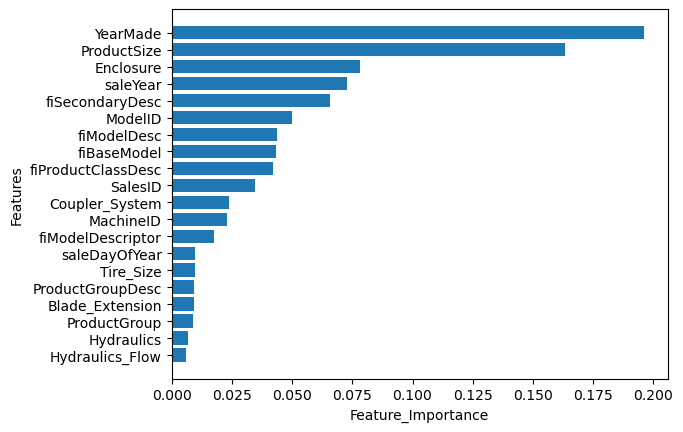

In [159]:
plot_features(X_train.columns, ideal_model.feature_importances_)

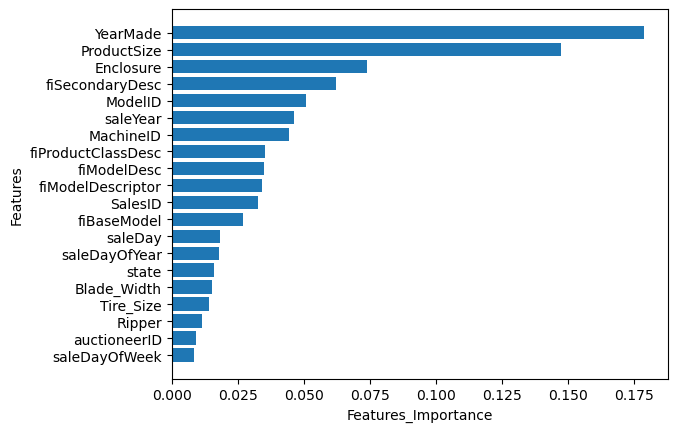

In [ ]:
# Let's see what feature contribute more on the training
visualized_feature_importance = visualize_feature_importance(X_train.columns, model.feature_importances_)

**Note/Recomendation:** Try to search/know why knowing features importances is good and how does it help.